In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2

# Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [8]:
# Dataset Information
print(df.info())
print()
print(df.describe())
print()
print("Shape:", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.4865

In [9]:
# Check Missing Values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
# Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [11]:
# Remove Unnecessary Columns
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [33]:
# Encode Categorical Data
encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Fare_Log
0,0,3,1,-0.551060,0.475876,-0.500754,-0.527515,2,0.760070
1,1,1,0,0.611945,0.475876,-0.500754,0.695086,0,1.212247
2,1,3,0,-0.260308,-0.534545,-0.500754,-0.514627,2,0.766079
3,1,1,0,0.393881,0.475876,-0.500754,0.347909,2,1.103218
4,0,3,1,0.393881,-0.534545,-0.500754,-0.512240,2,0.767187


In [32]:
# Remove Duplicate Records
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("New Shape:", df.shape)

Duplicates: 0
New Shape: (775, 9)


In [15]:
# Normalization
normalizer = MinMaxScaler()
cols = ["Age", "Fare", "SibSp", "Parch"]
df[cols] = normalizer.fit_transform(df[cols])

print(df.head())

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
0         0       3    1  0.271174  0.125    0.0  0.014151         2
1         1       1    0  0.472229  0.125    0.0  0.139136         0
2         1       3    0  0.321438  0.000    0.0  0.015469         2
3         1       1    0  0.434531  0.125    0.0  0.103644         2
4         0       3    1  0.434531  0.000    0.0  0.015713         2


In [16]:
# Standardization
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

print(df.head())

   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked
0         0       3    1 -0.551060  0.475876 -0.500754 -0.527515         2
1         1       1    0  0.611945  0.475876 -0.500754  0.695086         0
2         1       3    0 -0.260308 -0.534545 -0.500754 -0.514627         2
3         1       1    0  0.393881  0.475876 -0.500754  0.347909         2
4         0       3    1  0.393881 -0.534545 -0.500754 -0.512240         2


In [17]:
# Log Transformation
df["Fare_Log"] = np.log1p(df["Fare"] - df["Fare"].min() + 1)
print(df[["Fare", "Fare_Log"]].head())

       Fare  Fare_Log
0 -0.527515  0.760070
1  0.695086  1.212247
2 -0.514627  0.766079
3  0.347909  1.103218
4 -0.512240  0.767187


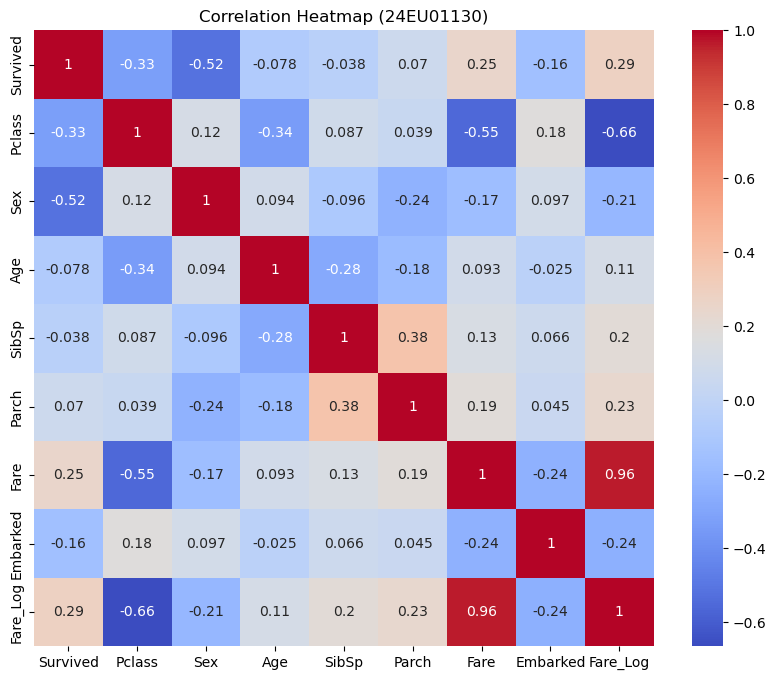

In [34]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (24EU01130)")
plt.show()

In [22]:
# Prepare Data for PCA
X = df.drop("Survived", axis=1)
y = df["Survived"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.33931077 0.21673058 0.12347364 0.11100878 0.08570523 0.07219681
 0.04890034 0.00267385]


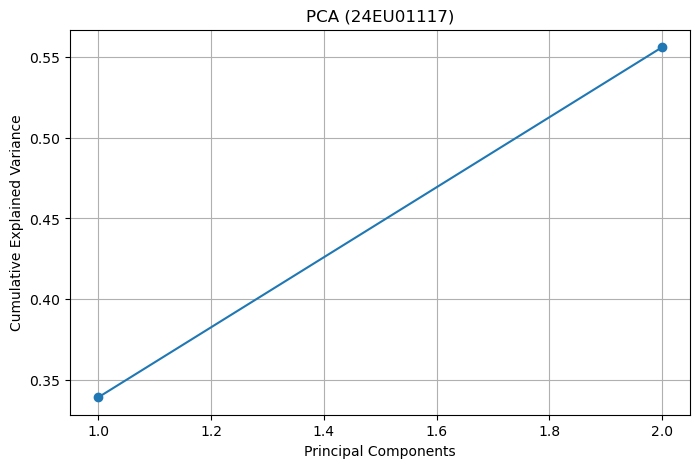

In [38]:
# PCA Graph
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA (24EU01117)")
plt.grid(True)
plt.show()

In [24]:
# PCA with Two Components
pca = PCA(n_components=2)
X_new = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_new.shape)

Shape after PCA: (775, 2)


In [26]:
# Feature Importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

    Feature  Importance
2       Age    0.250754
1       Sex    0.236303
5      Fare    0.173744
7  Fare_Log    0.163661
0    Pclass    0.074434
3     SibSp    0.040691
4     Parch    0.033599
6  Embarked    0.026813


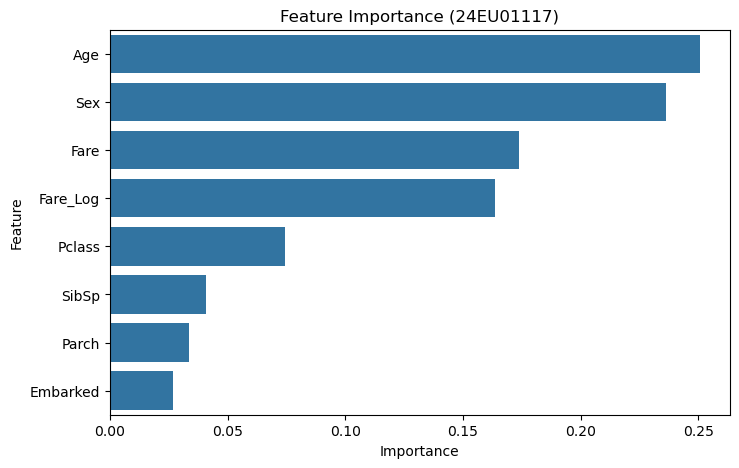

In [37]:
# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (24EU01117)")
plt.show()


In [28]:
# Feature Selection
X_chi = df.drop("Survived", axis=1)
X_chi = X_chi - X_chi.min()

selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X_chi, y)

print("Selected Features:")
print(X_chi.columns[selector.get_support()])

Selected Features:
Index(['Pclass', 'Sex', 'Fare', 'Embarked', 'Fare_Log'], dtype='object')


In [29]:
# Save Preprocessed Dataset
df.to_csv("Titanic_Preprocessed.csv", index=False)

print("Dataset Saved Successfully.")

Dataset Saved Successfully.
